# 05 — Classical Baselines (Subsampled)
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Establish classical ML benchmark performance under LOSO cross-validation on WESAD and
DREAMER using a **stratified subsample of 150 windows per class per fold**.

## Why Subsampled?
Quantum models (notebooks 07–08) are computationally constrained to small datasets
on classical hardware simulators. To ensure a **fair, apples-to-apples comparison**,
all classical and quantum models are evaluated on identical data conditions.
This is standard practice in QML benchmarking literature (Havlicek et al., 2019).

Documented in methodology as:
> *All models were evaluated on a stratified subsample of 150 windows per class per
> LOSO fold. This constraint was imposed by the computational cost of quantum kernel
> estimation under NISQ-era simulation.*

## Models
- Logistic Regression, SVM (RBF kernel), Random Forest

## Datasets & Tasks
| Dataset  | Task           | Labels                               |
|----------|----------------|--------------------------------------|
| WESAD    | Binary         | baseline(0) vs stress(1)             |
| WESAD    | 3-class        | baseline(0), stress(1), amusement(2) |
| DREAMER  | Binary (EEG)   | low arousal(0) vs high arousal(1)    |

## Key Design Decisions
- StandardScaler fitted on train fold only
- Median imputation fitted on train fold only
- class_weight='balanced' on all models
- Subsampling: stratified, random_state fixed for reproducibility
- Same subsample size used in QSVM and VQC notebooks

---


## 0. Configuration

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

warnings.filterwarnings('ignore')

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '05_classical_baselines')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

ECG_FEATURE_PREFIXES = ['ecg_']
RANDOM_STATE = 42

# ── Subsampling config ────────────────────────────────────────────────────────
N_SAMPLES_PER_CLASS = 150   # same value used in QSVM and VQC notebooks

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  Samples per class per fold : {N_SAMPLES_PER_CLASS}')
print(f'  Random state               : {RANDOM_STATE}')
print(f'  Plots dir                  : {os.path.abspath(PLOTS_DIR)}')


Configuration ready.
  Samples per class per fold : 150
  Random state               : 42
  Plots dir                  : c:\Users\ACER\Desktop\APPLIED RESEARCH\Applied-Research\results\plots\05_classical_baselines


## 1. Load Datasets

In [2]:
# WESAD
df_wesad_bin = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_binary.csv'))
df_wesad_3cl = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_3class.csv'))
wesad_feat_cols = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'feature_columns.json')))

# DREAMER — EEG features only
df_dreamer = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv'))
dreamer_all_feats = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'dreamer_feature_columns.json')))
dreamer_eeg_feats = [c for c in dreamer_all_feats
                     if not any(c.startswith(p) for p in ECG_FEATURE_PREFIXES)]

print('=== Datasets Loaded ===')
print(f'WESAD binary  : {df_wesad_bin.shape}  features={len(wesad_feat_cols)}')
print(f'WESAD 3-class : {df_wesad_3cl.shape}')
print(f'DREAMER binary: {df_dreamer.shape}  EEG features={len(dreamer_eeg_feats)}')

wesad_subjects   = sorted(df_wesad_bin['subject_id'].unique())
dreamer_subjects = sorted(df_dreamer['subject_id'].unique())
print(f'\nWESAD subjects  : {wesad_subjects}')
print(f'DREAMER subjects: {dreamer_subjects}')


=== Datasets Loaded ===
WESAD binary  : (883, 30)  features=26
WESAD 3-class : (1049, 30)
DREAMER binary: (414, 146)  EEG features=134

WESAD subjects  : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
DREAMER subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


## 1b. Fix DREAMER Ratings (if needed)
Only run this cell if `df_dreamer` is empty or has all-NaN arousal_binary.
Skips automatically if DREAMER is already correct.

In [3]:
if len(df_dreamer) == 0 or df_dreamer['arousal_binary'].isna().all():
    print('DREAMER ratings broken — re-extracting with correct keys...')
    from scipy.io import loadmat

    DREAMER_PATH = r"C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/DREAMER/DREAMER.mat"
    mat      = loadmat(DREAMER_PATH, simplify_cells=True)
    data_all = mat['DREAMER']['Data']

    rating_rows = []
    for sid in range(23):
        s   = data_all[sid]
        val = np.array(s['ScoreValence']).flatten()
        aro = np.array(s['ScoreArousal']).flatten()
        dom = np.array(s['ScoreDominance']).flatten()
        for vid in range(len(aro)):
            rating_rows.append({
                'subject_id'    : sid + 1,
                'video_id'      : vid + 1,
                'valence'       : float(val[vid]),
                'arousal'       : float(aro[vid]),
                'dominance'     : float(dom[vid]),
                'arousal_binary': int(aro[vid] > 3),
                'valence_binary': int(val[vid] > 3),
            })

    df_ratings_fixed = pd.DataFrame(rating_rows)
    df_dreamer_full  = pd.read_csv(
        os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_all.csv'))
    drop_cols = ['valence','arousal','dominance','arousal_binary','valence_binary']
    df_dreamer_full = df_dreamer_full.drop(
        columns=[c for c in drop_cols if c in df_dreamer_full.columns])
    df_dreamer = df_dreamer_full.merge(
        df_ratings_fixed, on=['subject_id','video_id'], how='left')
    df_dreamer = df_dreamer.dropna(subset=['arousal_binary']).copy()
    df_dreamer['arousal_binary'] = df_dreamer['arousal_binary'].astype(int)

    p = os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv')
    df_dreamer.to_csv(p, index=False)
    print(f'Fixed and saved: {p}')
    print(f'arousal_binary counts:\n{df_dreamer["arousal_binary"].value_counts()}')
else:
    print('DREAMER ratings OK — no fix needed.')
    print(f'arousal_binary counts:\n{df_dreamer["arousal_binary"].value_counts()}')

dreamer_subjects = sorted(df_dreamer['subject_id'].unique())
print(f'\nDREAMER subjects: {len(dreamer_subjects)}')


DREAMER ratings OK — no fix needed.
arousal_binary counts:
arousal_binary
0    233
1    181
Name: count, dtype: int64

DREAMER subjects: 23


## 2. Subsampling & Model Utilities

In [4]:
def stratified_subsample(X, y, n_per_class, random_state=42):
    """
    Subsample n_per_class examples from each class.
    If a class has fewer than n_per_class samples, take all of them
    and log a warning.
    """
    X_parts, y_parts = [], []
    rng = np.random.RandomState(random_state)

    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        if len(idx) <= n_per_class:
            chosen = idx
        else:
            chosen = rng.choice(idx, size=n_per_class, replace=False)
        X_parts.append(X[chosen])
        y_parts.append(y[chosen])

    X_out = np.vstack(X_parts)
    y_out = np.concatenate(y_parts)

    # Shuffle
    perm  = rng.permutation(len(y_out))
    return X_out[perm], y_out[perm]


def get_models():
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, class_weight='balanced',
            random_state=RANDOM_STATE),
        'SVM (RBF)': SVC(
            kernel='rbf', class_weight='balanced',
            random_state=RANDOM_STATE, probability=True),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1),
    }


def compute_metrics(y_true, y_pred, average='macro'):
    return {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'f1'       : float(f1_score(y_true, y_pred,
                           average=average, zero_division=0)),
    }


def run_loso(df, feature_cols, label_col, subject_col,
             task_name='task', average='macro',
             n_per_class=N_SAMPLES_PER_CLASS):
    """
    LOSO cross-validation with per-fold stratified subsampling.
    Subsampling applied to TRAIN set only — test set always uses
    all available windows for that subject.
    """
    subjects = sorted(df[subject_col].unique())
    classes  = sorted(df[label_col].unique())
    n_cls    = len(classes)

    fold_rows = []
    cm_dict   = {name: np.zeros((n_cls, n_cls), dtype=int)
                 for name in get_models()}
    all_preds = {name: {'y_true':[], 'y_pred':[]}
                 for name in get_models()}

    print(f'\n=== {task_name} — LOSO ({len(subjects)} folds) ===')
    print(f'    Train subsample : {n_per_class} per class')
    print(f'    Test            : all windows for held-out subject')

    for fold_i, test_sid in enumerate(subjects):
        train_mask = df[subject_col] != test_sid
        test_mask  = df[subject_col] == test_sid

        X_train = df.loc[train_mask, feature_cols].values.astype(float)
        y_train = df.loc[train_mask, label_col].values
        X_test  = df.loc[test_mask,  feature_cols].values.astype(float)
        y_test  = df.loc[test_mask,  label_col].values

        # Impute — fit on train only
        imputer = SimpleImputer(strategy='median')
        X_train = imputer.fit_transform(X_train)
        X_test  = imputer.transform(X_test)

        # Subsample train
        X_train_sub, y_train_sub = stratified_subsample(
            X_train, y_train,
            n_per_class=n_per_class,
            random_state=RANDOM_STATE + fold_i)

        # Scale — fit on subsampled train only
        scaler  = StandardScaler()
        X_train_sub = scaler.fit_transform(X_train_sub)
        X_test      = scaler.transform(X_test)

        models = get_models()
        for model_name, model in models.items():
            t0 = time.time()
            model.fit(X_train_sub, y_train_sub)
            train_time = time.time() - t0

            t0 = time.time()
            y_pred = model.predict(X_test)
            test_time = time.time() - t0

            metrics = compute_metrics(y_test, y_pred, average=average)
            cm      = confusion_matrix(y_test, y_pred, labels=classes)
            cm_dict[model_name] += cm

            all_preds[model_name]['y_true'].extend(y_test.tolist())
            all_preds[model_name]['y_pred'].extend(y_pred.tolist())

            fold_rows.append({
                'task'          : task_name,
                'model'         : model_name,
                'fold'          : fold_i + 1,
                'test_subject'  : int(test_sid),
                'train_size'    : len(y_train_sub),
                'test_size'     : len(y_test),
                'train_time'    : round(train_time, 4),
                'test_time'     : round(test_time, 4),
                **metrics
            })

        if (fold_i + 1) % 5 == 0 or fold_i == 0:
            print(f'  Fold {fold_i+1:2d}/{len(subjects)} — '
                  f'test=S{test_sid}  '
                  f'train_sub={len(y_train_sub)}  '
                  f'test={len(y_test)}')

    return pd.DataFrame(fold_rows), cm_dict, all_preds


print('Utilities defined.')
print(f'Subsampling: {N_SAMPLES_PER_CLASS} per class per fold (train only).')
print('Test set: always full — no subsampling on test.')


Utilities defined.
Subsampling: 150 per class per fold (train only).
Test set: always full — no subsampling on test.


## 3. WESAD — Binary Task (baseline vs stress)

In [5]:
results_wb, cm_wb, preds_wb = run_loso(
    df           = df_wesad_bin,
    feature_cols = wesad_feat_cols,
    label_col    = 'label_encoded',
    subject_col  = 'subject_id',
    task_name    = 'WESAD_binary',
    average      = 'macro'
)
print('\n=== WESAD Binary — Mean Metrics ===')
print(results_wb.groupby('model')[['accuracy','precision','recall','f1',
                                    'train_time','test_time']]
      .mean().round(4).to_string())



=== WESAD_binary — LOSO (15 folds) ===
    Train subsample : 150 per class
    Test            : all windows for held-out subject
  Fold  1/15 — test=S2  train_sub=300  test=56
  Fold  5/15 — test=S6  train_sub=300  test=59
  Fold 10/15 — test=S11  train_sub=300  test=59
  Fold 15/15 — test=S17  train_sub=300  test=61

=== WESAD Binary — Mean Metrics ===
                     accuracy  precision  recall      f1  train_time  test_time
model                                                                          
Logistic Regression    0.8534     0.8611  0.8432  0.8197      0.0078     0.0006
Random Forest          0.8943     0.8931  0.8881  0.8769      0.2397     0.0340
SVM (RBF)              0.8862     0.8806  0.8603  0.8474      0.0099     0.0013


## 4. WESAD — 3-Class Task (baseline / stress / amusement)

In [6]:
results_w3, cm_w3, preds_w3 = run_loso(
    df           = df_wesad_3cl,
    feature_cols = wesad_feat_cols,
    label_col    = 'label_encoded',
    subject_col  = 'subject_id',
    task_name    = 'WESAD_3class',
    average      = 'macro'
)
print('\n=== WESAD 3-Class — Mean Metrics ===')
print(results_w3.groupby('model')[['accuracy','precision','recall','f1',
                                    'train_time','test_time']]
      .mean().round(4).to_string())



=== WESAD_3class — LOSO (15 folds) ===
    Train subsample : 150 per class
    Test            : all windows for held-out subject
  Fold  1/15 — test=S2  train_sub=450  test=67
  Fold  5/15 — test=S6  train_sub=450  test=70
  Fold 10/15 — test=S11  train_sub=450  test=70
  Fold 15/15 — test=S17  train_sub=450  test=72

=== WESAD 3-Class — Mean Metrics ===
                     accuracy  precision  recall      f1  train_time  test_time
model                                                                          
Logistic Regression    0.6460     0.6747  0.6632  0.5856      0.0218     0.0000
Random Forest          0.6995     0.6944  0.6731  0.6344      0.3498     0.0408
SVM (RBF)              0.6399     0.6814  0.6423  0.5872      0.0277     0.0032


## 5. DREAMER — Binary Task (EEG features only)

In [7]:
results_db, cm_db, preds_db = run_loso(
    df           = df_dreamer,
    feature_cols = dreamer_eeg_feats,
    label_col    = 'arousal_binary',
    subject_col  = 'subject_id',
    task_name    = 'DREAMER_binary_EEG',
    average      = 'macro'
)
print('\n=== DREAMER Binary EEG — Mean Metrics ===')
print(results_db.groupby('model')[['accuracy','precision','recall','f1',
                                    'train_time','test_time']]
      .mean().round(4).to_string())



=== DREAMER_binary_EEG — LOSO (23 folds) ===
    Train subsample : 150 per class
    Test            : all windows for held-out subject
  Fold  1/23 — test=S1  train_sub=300  test=18
  Fold  5/23 — test=S5  train_sub=300  test=18
  Fold 10/23 — test=S10  train_sub=300  test=18
  Fold 15/23 — test=S15  train_sub=300  test=18
  Fold 20/23 — test=S20  train_sub=300  test=18

=== DREAMER Binary EEG — Mean Metrics ===
                     accuracy  precision  recall      f1  train_time  test_time
model                                                                          
Logistic Regression    0.4952     0.4998  0.5000  0.4695      0.0490     0.0002
Random Forest          0.5121     0.5418  0.5244  0.4722      0.2971     0.0415
SVM (RBF)              0.5072     0.4063  0.4746  0.4016      0.0238     0.0021


## 6. Results Summary Table

In [8]:
all_results = pd.concat([results_wb, results_w3, results_db], ignore_index=True)

summary_all = (
    all_results
    .groupby(['task','model'])
    .agg(
        accuracy_mean  = ('accuracy',   'mean'),
        accuracy_std   = ('accuracy',   'std'),
        precision_mean = ('precision',  'mean'),
        recall_mean    = ('recall',     'mean'),
        f1_mean        = ('f1',         'mean'),
        f1_std         = ('f1',         'std'),
        train_time_mean= ('train_time', 'mean'),
        test_time_mean = ('test_time',  'mean'),
    )
    .round(4)
    .reset_index()
)

print('=== CLASSICAL BASELINES — FULL SUMMARY ===')
print(f'(Subsampled: {N_SAMPLES_PER_CLASS} per class per fold)')
print(summary_all.to_string(index=False))

p = os.path.join(OUTPUT_DATA_DIR, 'classical_baselines_summary.csv')
summary_all.to_csv(p, index=False)
print(f'\nSaved: {p}')

p2 = os.path.join(OUTPUT_DATA_DIR, 'classical_baselines_per_fold.csv')
all_results.to_csv(p2, index=False)
print(f'Saved: {p2}')


=== CLASSICAL BASELINES — FULL SUMMARY ===
(Subsampled: 150 per class per fold)
              task               model  accuracy_mean  accuracy_std  precision_mean  recall_mean  f1_mean  f1_std  train_time_mean  test_time_mean
DREAMER_binary_EEG Logistic Regression         0.4952        0.1339          0.4998       0.5000   0.4695  0.1435           0.0490          0.0002
DREAMER_binary_EEG       Random Forest         0.5121        0.1264          0.5418       0.5244   0.4722  0.1275           0.2971          0.0415
DREAMER_binary_EEG           SVM (RBF)         0.5072        0.1246          0.4063       0.4746   0.4016  0.1135           0.0238          0.0021
      WESAD_3class Logistic Regression         0.6460        0.1635          0.6747       0.6632   0.5856  0.1779           0.0218          0.0000
      WESAD_3class       Random Forest         0.6995        0.1483          0.6944       0.6731   0.6344  0.1283           0.3498          0.0408
      WESAD_3class           SVM (RBF)

## 7. Confusion Matrices

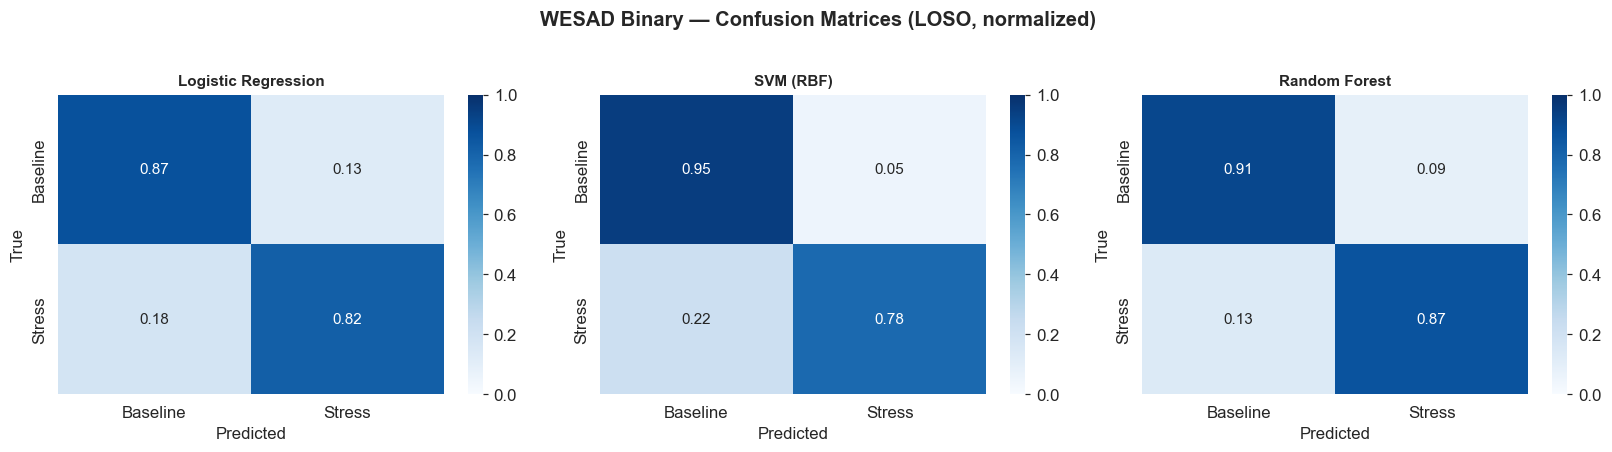

Saved: ..\results\plots\05_classical_baselines\cm_wesad_binary.png


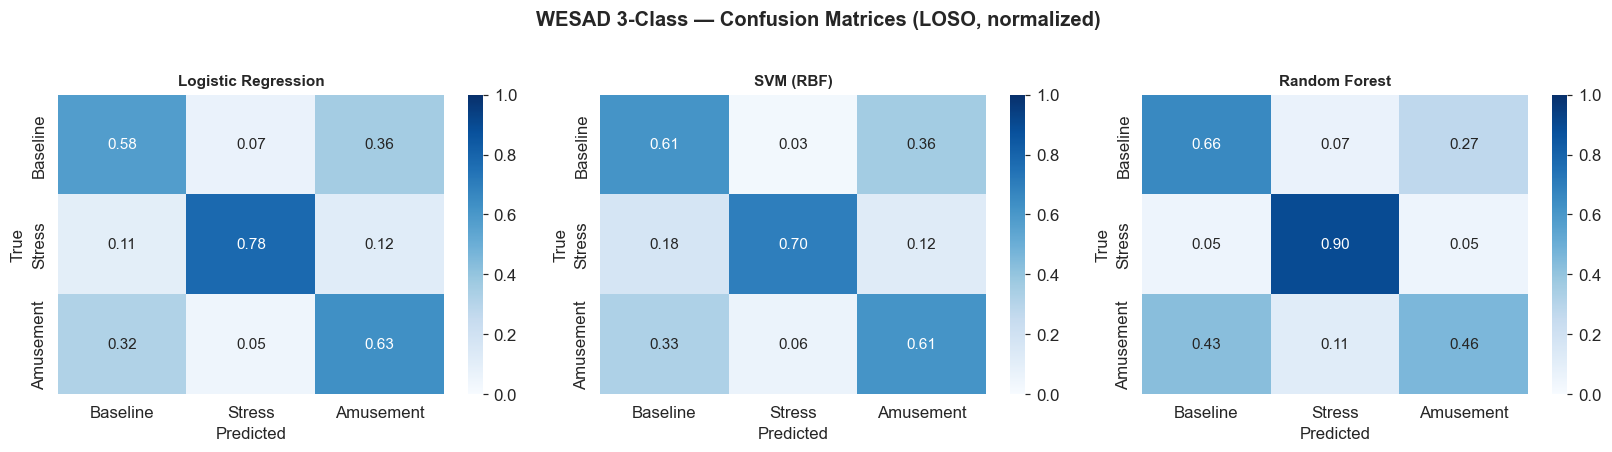

Saved: ..\results\plots\05_classical_baselines\cm_wesad_3class.png


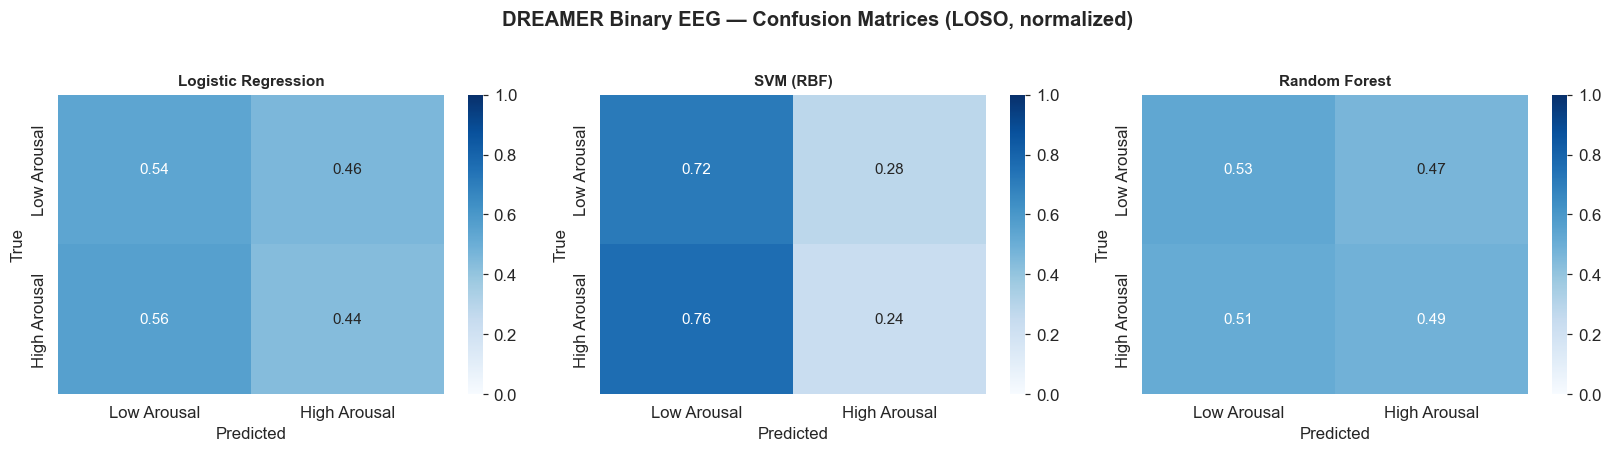

Saved: ..\results\plots\05_classical_baselines\cm_dreamer_binary.png


In [9]:
def plot_confusion_matrices(cm_dict, class_names, title, save_path):
    n = len(cm_dict)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for ax, (model_name, cm) in zip(axes, cm_dict.items()):
        cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, vmin=0, vmax=1, annot_kws={'size':10})
        ax.set_title(model_name, fontweight='bold', fontsize=10)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    plt.suptitle(title, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_confusion_matrices(
    cm_wb, ['Baseline','Stress'],
    'WESAD Binary — Confusion Matrices (LOSO, normalized)',
    os.path.join(PLOTS_DIR, 'cm_wesad_binary.png'))

plot_confusion_matrices(
    cm_w3, ['Baseline','Stress','Amusement'],
    'WESAD 3-Class — Confusion Matrices (LOSO, normalized)',
    os.path.join(PLOTS_DIR, 'cm_wesad_3class.png'))

plot_confusion_matrices(
    cm_db, ['Low Arousal','High Arousal'],
    'DREAMER Binary EEG — Confusion Matrices (LOSO, normalized)',
    os.path.join(PLOTS_DIR, 'cm_dreamer_binary.png'))


## 8. Performance Comparison Plots

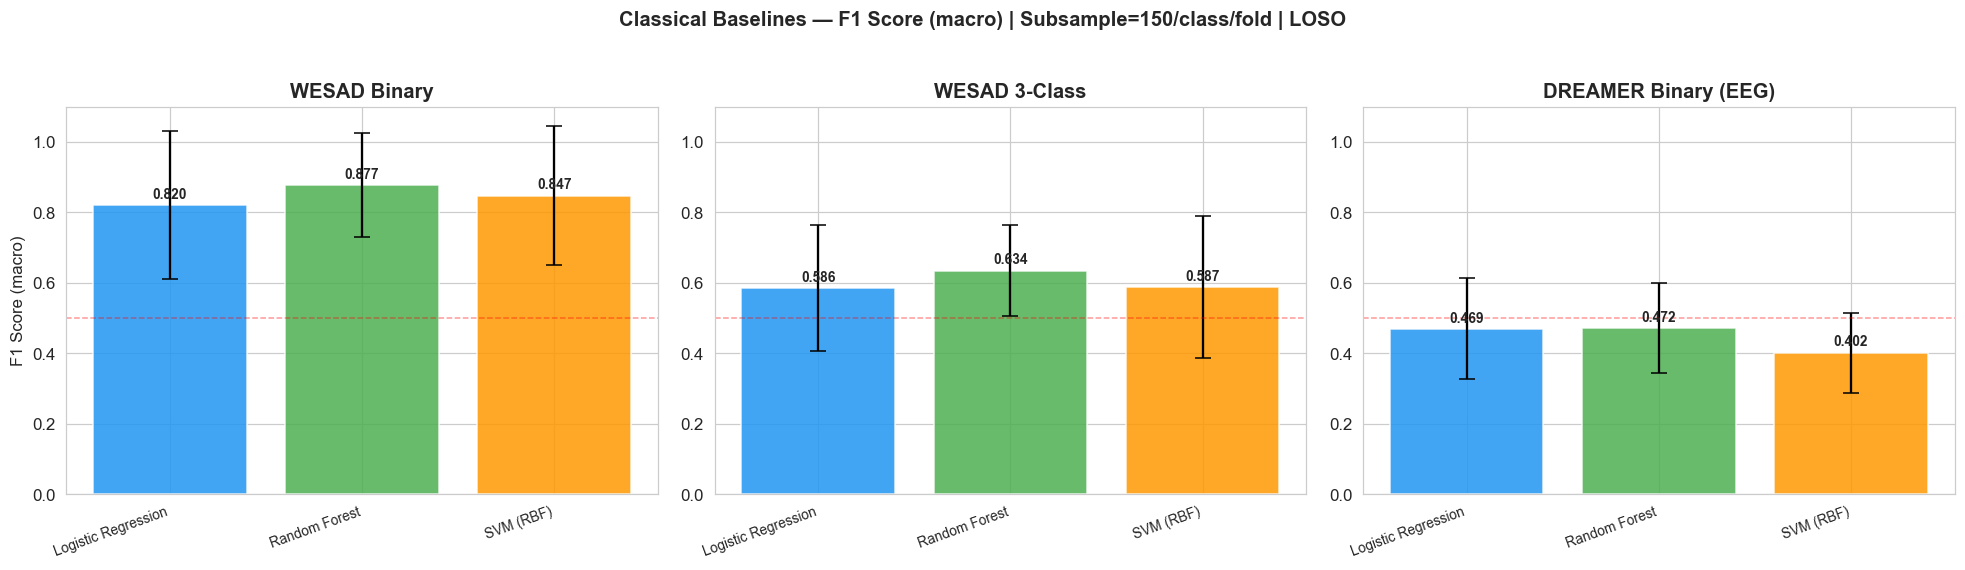

Saved: ..\results\plots\05_classical_baselines\classical_f1_comparison.png


In [10]:
tasks = [
    ('WESAD_binary',      'WESAD Binary'),
    ('WESAD_3class',      'WESAD 3-Class'),
    ('DREAMER_binary_EEG','DREAMER Binary (EEG)'),
]
model_colors = {
    'Logistic Regression': '#2196F3',
    'SVM (RBF)'          : '#FF9800',
    'Random Forest'      : '#4CAF50',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (task_key, task_label) in zip(axes, tasks):
    td      = summary_all[summary_all['task'] == task_key]
    models  = td['model'].tolist()
    f1_m    = td['f1_mean'].tolist()
    f1_s    = td['f1_std'].tolist()
    colors  = [model_colors.get(m, 'gray') for m in models]
    bars    = ax.bar(models, f1_m, color=colors, alpha=0.85,
                     yerr=f1_s, capsize=5, edgecolor='white')
    for bar, val in zip(bars, f1_m):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 Score (macro)' if ax == axes[0] else '')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.4, label='chance')

plt.suptitle(
    f'Classical Baselines — F1 Score (macro) | '
    f'Subsample={N_SAMPLES_PER_CLASS}/class/fold | LOSO',
    fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'classical_f1_comparison.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


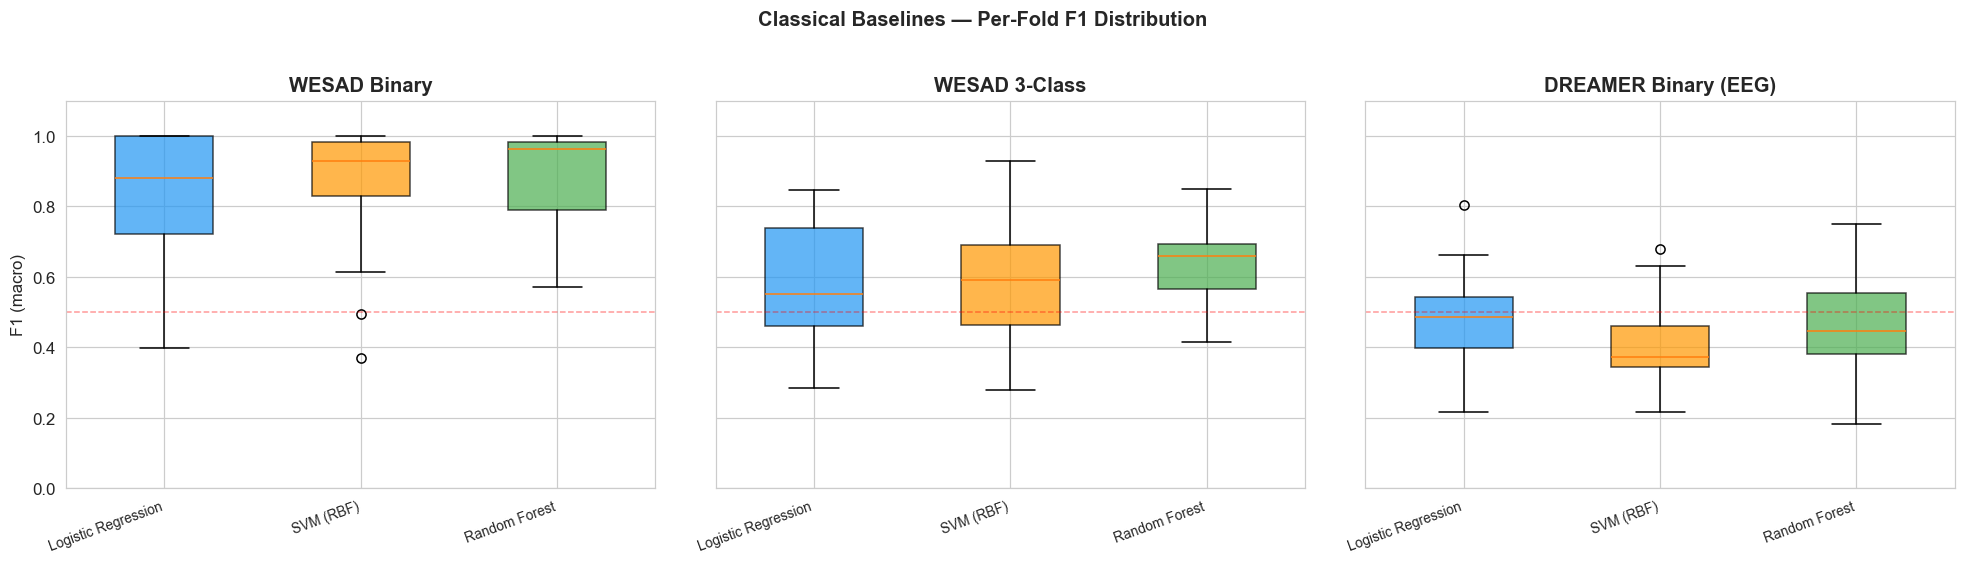

Saved: ..\results\plots\05_classical_baselines\classical_f1_per_fold_boxplot.png


In [11]:
# Per-fold F1 boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (task_key, task_label) in zip(axes, tasks):
    td          = all_results[all_results['task'] == task_key]
    model_names = list(td['model'].unique())
    data        = [td[td['model']==m]['f1'].values for m in model_names]
    bp = ax.boxplot(data, patch_artist=True,
                    labels=model_names, widths=0.5)
    for patch, m in zip(bp['boxes'], model_names):
        patch.set_facecolor(model_colors.get(m, 'gray'))
        patch.set_alpha(0.7)
    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)' if ax == axes[0] else '')
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.4)
plt.suptitle('Classical Baselines — Per-Fold F1 Distribution',
             fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'classical_f1_per_fold_boxplot.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


## 9. WESAD 3-Class: Stress vs Amusement Overlap Analysis
Measures how often classical models confuse stress with amusement —
the baseline overlap rate that quantum models will be compared against.

In [12]:
print('=== Stress/Amusement Confusion (WESAD 3-class) ===')
print('Classes: 0=baseline  1=stress  2=amusement')
print()
overlap_rows = []
for model_name, cm in cm_w3.items():
    total_stress = cm[1, :].sum()
    total_amuse  = cm[2, :].sum()
    s_as_a = cm[1, 2]
    a_as_s = cm[2, 1]
    s_a_rate = s_as_a / total_stress if total_stress > 0 else 0
    a_s_rate = a_as_s / total_amuse  if total_amuse  > 0 else 0
    overlap_rows.append({
        'model'                  : model_name,
        'stress->amusement_rate' : round(s_a_rate, 4),
        'amusement->stress_rate' : round(a_s_rate, 4),
    })
    print(f'  {model_name}:')
    print(f'    Stress -> Amusement : {s_as_a}/{total_stress} ({s_a_rate*100:.1f}%)')
    print(f'    Amusement -> Stress : {a_as_s}/{total_amuse}  ({a_s_rate*100:.1f}%)')
    print()

df_overlap = pd.DataFrame(overlap_rows)
p = os.path.join(OUTPUT_DATA_DIR, 'classical_stress_amusement_overlap.csv')
df_overlap.to_csv(p, index=False)
print(f'Saved: {p}')
print('These rates are the classical baseline for the overlap problem.')
print('Quantum models will be compared against these in the results analysis.')


=== Stress/Amusement Confusion (WESAD 3-class) ===
Classes: 0=baseline  1=stress  2=amusement

  Logistic Regression:
    Stress -> Amusement : 36/313 (11.5%)
    Amusement -> Stress : 8/166  (4.8%)

  SVM (RBF):
    Stress -> Amusement : 39/313 (12.5%)
    Amusement -> Stress : 10/166  (6.0%)

  Random Forest:
    Stress -> Amusement : 16/313 (5.1%)
    Amusement -> Stress : 19/166  (11.4%)

Saved: ..\results\output_data\classical_stress_amusement_overlap.csv
These rates are the classical baseline for the overlap problem.
Quantum models will be compared against these in the results analysis.


## 10. Summary Log

In [13]:
summary_dict = {
    'notebook'          : '05_classical_baselines',
    'timestamp'         : datetime.now().isoformat(),
    'subsampling'       : {
        'n_per_class'   : N_SAMPLES_PER_CLASS,
        'applied_to'    : 'train fold only',
        'test_set'      : 'all windows for held-out subject (no subsampling)',
        'justification' : 'Matches quantum model evaluation conditions'
    },
    'models'            : ['Logistic Regression', 'SVM (RBF)', 'Random Forest'],
    'tasks'             : [
        'WESAD_binary', 'WESAD_3class', 'DREAMER_binary_EEG'],
    'evaluation'        : 'Leave-One-Subject-Out (LOSO)',
    'results'           : {}
}

for _, row in summary_all.iterrows():
    key = f"{row['task']}|{row['model']}"
    summary_dict['results'][key] = {
        'accuracy_mean': row['accuracy_mean'],
        'f1_mean'      : row['f1_mean'],
        'f1_std'       : row['f1_std'],
        'train_time_s' : row['train_time_mean'],
    }

summary_dict['next'] = '06_cnn_baseline.ipynb'

p = os.path.join(LOGS_DIR, '05_classical_baselines_summary.json')
with open(p,'w') as f: json.dump(summary_dict, f, indent=2)

print('=' * 60)
print('CLASSICAL BASELINES COMPLETE')
print('=' * 60)
print(json.dumps(summary_dict, indent=2))
print(f'\nLog saved: {p}')


CLASSICAL BASELINES COMPLETE
{
  "notebook": "05_classical_baselines",
  "timestamp": "2026-05-09T19:00:58.350991",
  "subsampling": {
    "n_per_class": 150,
    "applied_to": "train fold only",
    "test_set": "all windows for held-out subject (no subsampling)",
    "justification": "Matches quantum model evaluation conditions"
  },
  "models": [
    "Logistic Regression",
    "SVM (RBF)",
    "Random Forest"
  ],
  "tasks": [
    "WESAD_binary",
    "WESAD_3class",
    "DREAMER_binary_EEG"
  ],
  "evaluation": "Leave-One-Subject-Out (LOSO)",
  "results": {
    "DREAMER_binary_EEG|Logistic Regression": {
      "accuracy_mean": 0.4952,
      "f1_mean": 0.4695,
      "f1_std": 0.1435,
      "train_time_s": 0.049
    },
    "DREAMER_binary_EEG|Random Forest": {
      "accuracy_mean": 0.5121,
      "f1_mean": 0.4722,
      "f1_std": 0.1275,
      "train_time_s": 0.2971
    },
    "DREAMER_binary_EEG|SVM (RBF)": {
      "accuracy_mean": 0.5072,
      "f1_mean": 0.4016,
      "f1_std": 0.1